# VetView — Veterinaria North S.A.C.
## APF3 · Módulo de Machine Learning — Comparación de Modelos
**Curso:** Innovación y Transformación Digital (100000TD09) — Ciclo 2026-1
**Grupo 2** — Sección 25367

Este notebook entrena y compara tres algoritmos de clasificación
(**Regresión Logística, SVM y KNN**) para detectar comportamientos
anómalos en los eventos de monitoreo IoT de Veterinaria North, usando
`GridSearchCV` para la optimización de hiperparámetros y `F1-score`
como métrica principal de selección (dado el desbalance de clases).

**Reproducibilidad:** `random_state = 42` en todos los pasos estocásticos.

## 0. Instalación de dependencias (opcional)

In [1]:
# !pip install pandas numpy scikit-learn matplotlib seaborn

## 1. Importación de librerías

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

## 2. Generación / carga del dataset

Si `vetview_dataset_clean.csv` no existe en el directorio de trabajo, se
genera un dataset simulado de 600 registros con la misma regla de
negocio (definida por el Dr. North) usada para etiquetar comportamientos
anómalos.

In [3]:
def generar_dataset_simulado():
    """
    Genera el dataset simulado de 600 registros para Veterinaria North.
    Basado en los umbrales clinicos definidos en el diagnostico.
    """
    np.random.seed(42)
    n = 600

    # Variables base
    tipo_servicio = np.random.choice(['Bano', 'Hospitalizacion'], n, p=[0.4, 0.6])
    duracion = np.where(tipo_servicio == 'Bano',
                        np.random.normal(45, 8, n).clip(20, 80),
                        np.random.normal(1400, 600, n).clip(120, 3000))

    # Caracteristicas de los sensores IoT
    movimiento = np.random.beta(2, 5, n) * 100
    quietud = np.random.exponential(50, n).clip(0, 2000)
    vocalizacion = np.random.exponential(3, n).clip(0, 70)

    # Regla de negocio para anomalia (definida por el Dr. North)
    ratio = quietud / duracion
    anomalo = ((vocalizacion > 10) & (movimiento < 20)) | (ratio > 0.5)
    target = anomalo.astype(int)

    # Crear DataFrame
    df = pd.DataFrame({
        'id_paciente': np.arange(1, n+1),
        'tipo_servicio': tipo_servicio,
        'duracion_servicio_min': duracion,
        'nivel_movimiento_pct': movimiento,
        'tiempo_quietud_min': quietud,
        'tiempo_vocalizacion_min': vocalizacion,
        'ratio_inactividad_clinica': quietud / duracion,
        'target_anomalo': target
    })

    return df

print("="*80)
print("VETVIEW - SISTEMA DE MONITOREO VETERINARIO")
print("MODULO DE MACHINE LEARNING - APF3")
print("COMPARACION: Regresion Logistica vs SVM vs KNN")
print("="*80)

if not os.path.exists("vetview_dataset_clean.csv"):
    print("\n\u26a0\ufe0f Generando dataset simulado...")
    df = generar_dataset_simulado()
    df.to_csv("vetview_dataset_clean.csv", index=False)
    print(f"\u2705 Dataset guardado: {df.shape[0]} registros")
else:
    df = pd.read_csv("vetview_dataset_clean.csv")
    print(f"\n\u2705 Dataset cargado: {df.shape[0]} registros")

VETVIEW - SISTEMA DE MONITOREO VETERINARIO
MODULO DE MACHINE LEARNING - APF3
COMPARACION: Regresion Logistica vs SVM vs KNN

⚠️ Generando dataset simulado...
✅ Dataset guardado: 600 registros


## 3. Análisis Exploratorio de Datos (EDA)

In [4]:
print("\n" + "="*80)
print("ANALISIS EXPLORATORIO DE DATOS (EDA)")
print("="*80)

# Estadisticos descriptivos
print("\n\U0001F4CA Estadisticos Descriptivos:")
print(df.describe())

# Distribucion del target
print(f"\n\U0001F4CA Distribucion del target:")
print(df['target_anomalo'].value_counts())
print(f"Porcentaje de casos anomalos: {(df['target_anomalo'].sum()/len(df))*100:.2f}%")


ANALISIS EXPLORATORIO DE DATOS (EDA)

📊 Estadisticos Descriptivos:
       id_paciente  duracion_servicio_min  nivel_movimiento_pct  \
count   600.000000             600.000000            600.000000   
mean    300.500000             872.768043             28.439984   
std     173.349358             828.997699             15.576247   
min       1.000000              25.226844              0.724791   
25%     150.750000              47.445838             16.800127   
50%     300.500000             820.684017             25.958615   
75%     450.250000            1567.934366             38.935752   
max     600.000000            2961.009869             81.334241   

       tiempo_quietud_min  tiempo_vocalizacion_min  ratio_inactividad_clinica  \
count          600.000000               600.000000                 600.000000   
mean            49.543392                 3.041732                   0.475522   
std             49.240408                 3.036996                   0.878538   
min 

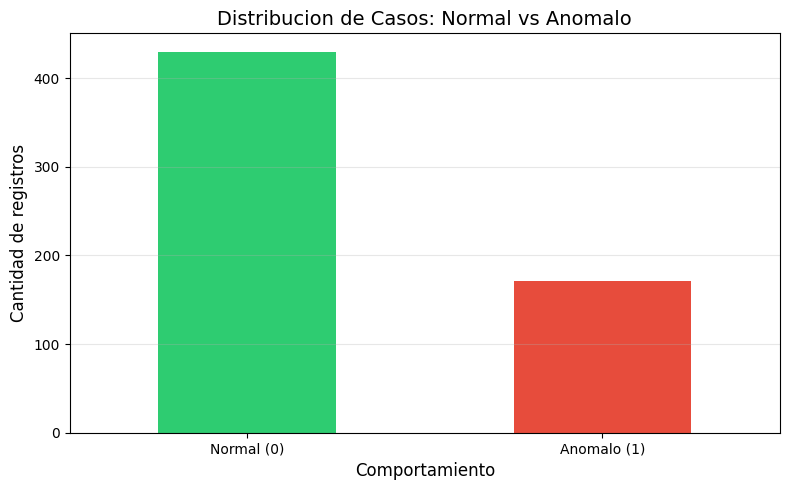

In [5]:
# Visualizacion: distribucion del target
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['target_anomalo'].value_counts().plot(kind='bar', color=colors)
plt.title('Distribucion de Casos: Normal vs Anomalo', fontsize=14)
plt.xlabel('Comportamiento', fontsize=12)
plt.ylabel('Cantidad de registros', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Anomalo (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100)
plt.show()

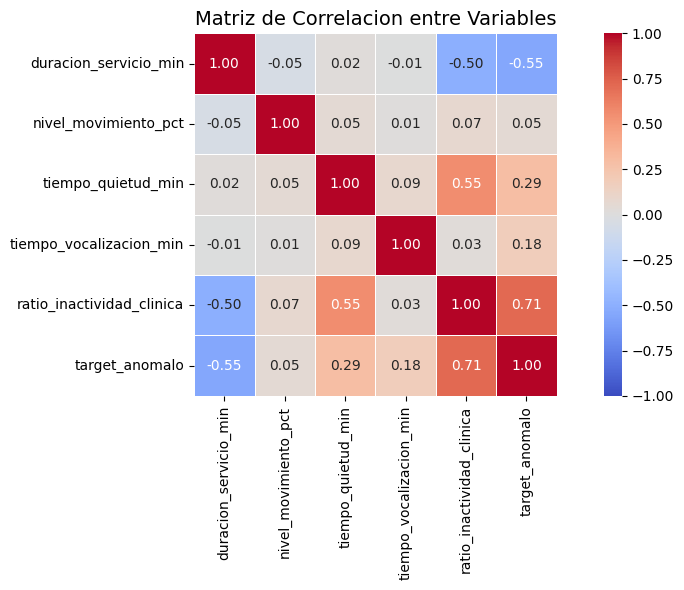

In [6]:
# Matriz de correlacion
plt.figure(figsize=(10, 6))
corr = df.drop(columns=['id_paciente']).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlacion entre Variables', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=100)
plt.show()

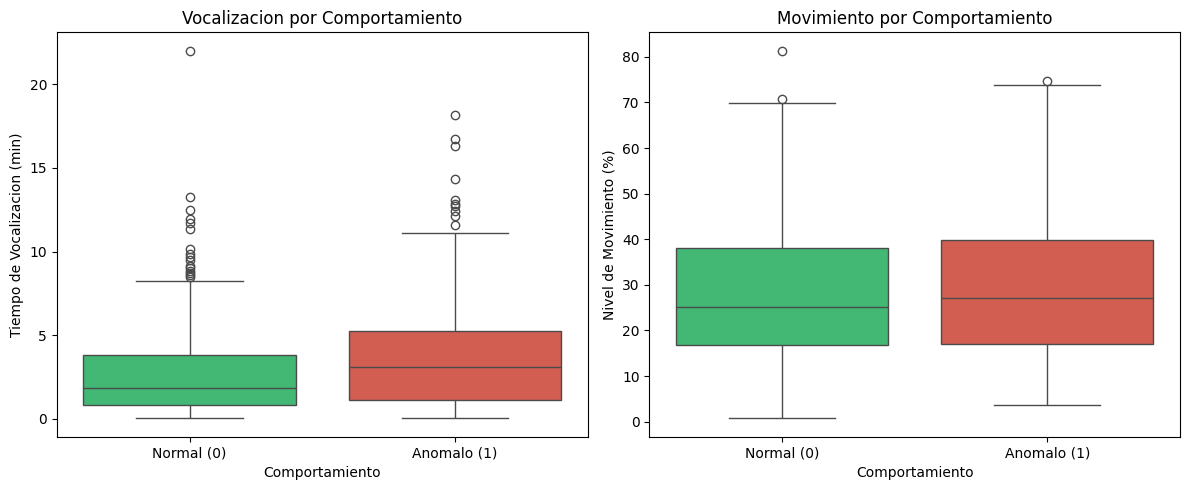

In [7]:
# Boxplot bivariado: vocalizacion / movimiento por tipo de comportamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vocalizacion vs target
sns.boxplot(x='target_anomalo', y='tiempo_vocalizacion_min', data=df, ax=axes[0],
            hue='target_anomalo', palette=['#2ecc71', '#e74c3c'], legend=False)
axes[0].set_title('Vocalizacion por Comportamiento', fontsize=12)
axes[0].set_xlabel('Comportamiento', fontsize=10)
axes[0].set_ylabel('Tiempo de Vocalizacion (min)', fontsize=10)
axes[0].set_xticklabels(['Normal (0)', 'Anomalo (1)'])

# Movimiento vs target
sns.boxplot(x='target_anomalo', y='nivel_movimiento_pct', data=df, ax=axes[1],
            hue='target_anomalo', palette=['#2ecc71', '#e74c3c'], legend=False)
axes[1].set_title('Movimiento por Comportamiento', fontsize=12)
axes[1].set_xlabel('Comportamiento', fontsize=10)
axes[1].set_ylabel('Nivel de Movimiento (%)', fontsize=10)
axes[1].set_xticklabels(['Normal (0)', 'Anomalo (1)'])

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=100)
plt.show()

## 4. Separación de variables

In [8]:
print("\n" + "="*80)
print("SEPARACION DE VARIABLES")
print("="*80)

# Separar X (variables predictoras) y y (target)
X = df.drop(columns=['id_paciente', 'target_anomalo'])
y = df['target_anomalo']

# Identificar tipos de columnas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables predictoras: {X.shape[1]}")
print(f"  - Numericas ({len(numeric_cols)}): {', '.join(numeric_cols)}")
print(f"  - Categoricas ({len(categorical_cols)}): {', '.join(categorical_cols)}")
print(f"Variable objetivo: target_anomalo")


SEPARACION DE VARIABLES
Variables predictoras: 6
  - Numericas (5): duracion_servicio_min, nivel_movimiento_pct, tiempo_quietud_min, tiempo_vocalizacion_min, ratio_inactividad_clinica
  - Categoricas (1): tipo_servicio
Variable objetivo: target_anomalo


## 5. Preprocesamiento

In [9]:
print("\n" + "="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# Crear preprocesador con escalado para SVM y KNN
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # Escalado para SVM y KNN
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

print("\u2705 Preprocesador creado:")
print("   - StandardScaler aplicado a variables numericas")
print("   - OneHotEncoder aplicado a variables categoricas")
print("   - Nota: El escalado es CRITICO para SVM y KNN")


PREPROCESAMIENTO DE DATOS
✅ Preprocesador creado:
   - StandardScaler aplicado a variables numericas
   - OneHotEncoder aplicado a variables categoricas
   - Nota: El escalado es CRITICO para SVM y KNN


## 6. División del dataset (Train/Test)

In [10]:
print("\n" + "="*80)
print("DIVISION DEL DATASET (Train/Test)")
print("="*80)

# Dividir con estratificacion (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\U0001F4CA Conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"   - Normales: {(y_train == 0).sum()} ({((y_train == 0).sum()/len(y_train))*100:.1f}%)")
print(f"   - Anomalos: {(y_train == 1).sum()} ({((y_train == 1).sum()/len(y_train))*100:.1f}%)")

print(f"\n\U0001F4CA Conjunto de prueba: {X_test.shape[0]} registros")
print(f"   - Normales: {(y_test == 0).sum()} ({((y_test == 0).sum()/len(y_test))*100:.1f}%)")
print(f"   - Anomalos: {(y_test == 1).sum()} ({((y_test == 1).sum()/len(y_test))*100:.1f}%)")


DIVISION DEL DATASET (Train/Test)
📊 Conjunto de entrenamiento: 480 registros
   - Normales: 343 (71.5%)
   - Anomalos: 137 (28.5%)

📊 Conjunto de prueba: 120 registros
   - Normales: 86 (71.7%)
   - Anomalos: 34 (28.3%)


## 7. Entrenamiento y optimización de hiperparámetros

Se entrenan tres modelos con `GridSearchCV` (5 folds, `scoring='f1'`):
Regresión Logística, SVM y KNN.

### 7.1 Regresión Logística

In [11]:
print("\n" + "="*40)
print("\U0001F50D MODELO 1: REGRESION LOGISTICA")
print("="*40)

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__class_weight': ['balanced', None]
}

print("\U0001F50E Realizando Grid Search para Regresion Logistica...")
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print(f"\n\u2705 Mejores parametros: {grid_lr.best_params_}")
print(f"   F1 promedio en validacion: {grid_lr.best_score_:.4f}")
mejor_lr = grid_lr.best_estimator_


🔍 MODELO 1: REGRESION LOGISTICA
🔎 Realizando Grid Search para Regresion Logistica...
Fitting 5 folds for each of 16 candidates, totalling 80 fits



✅ Mejores parametros: {'classifier__C': 100, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}
   F1 promedio en validacion: 0.9594


### 7.2 SVM (Support Vector Machine)

In [12]:
print("\n" + "="*40)
print("\U0001F50D MODELO 2: SVM (Support Vector Machine)")
print("="*40)

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True))
])

param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto', 0.1, 1],
    'classifier__class_weight': ['balanced', None]
}

print("\U0001F50E Realizando Grid Search para SVM...")
grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)

print(f"\n\u2705 Mejores parametros: {grid_svm.best_params_}")
print(f"   F1 promedio en validacion: {grid_svm.best_score_:.4f}")
mejor_svm = grid_svm.best_estimator_


🔍 MODELO 2: SVM (Support Vector Machine)
🔎 Realizando Grid Search para SVM...
Fitting 5 folds for each of 64 candidates, totalling 320 fits



✅ Mejores parametros: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
   F1 promedio en validacion: 0.9675


### 7.3 KNN (K-Nearest Neighbors)

In [13]:
print("\n" + "="*40)
print("\U0001F50D MODELO 3: KNN (K-Nearest Neighbors)")
print("="*40)

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan'],
    'classifier__p': [1, 2]
}

print("\U0001F50E Realizando Grid Search para KNN...")
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

print(f"\n\u2705 Mejores parametros: {grid_knn.best_params_}")
print(f"   F1 promedio en validacion: {grid_knn.best_score_:.4f}")
mejor_knn = grid_knn.best_estimator_


🔍 MODELO 3: KNN (K-Nearest Neighbors)
🔎 Realizando Grid Search para KNN...
Fitting 5 folds for each of 48 candidates, totalling 240 fits



✅ Mejores parametros: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'distance'}
   F1 promedio en validacion: 0.9444


## 8. Evaluación en conjunto de prueba

In [14]:
print("\n" + "="*80)
print("EVALUACION DE MODELOS EN CONJUNTO DE PRUEBA")
print("="*80)

def evaluar_modelo_completo(modelo, nombre, X_test, y_test):
    """
    Evalua un modelo y retorna todas las metricas relevantes.
    """
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else None

    metricas = {
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba,
        'matriz': confusion_matrix(y_test, y_pred)
    }

    if y_proba is not None:
        metricas['auc_roc'] = roc_auc_score(y_test, y_proba)

    return metricas

# Evaluar cada modelo
print("\n\U0001F4CA Evaluando modelos...")

resultado_lr = evaluar_modelo_completo(mejor_lr, 'Regresion Logistica', X_test, y_test)
resultado_svm = evaluar_modelo_completo(mejor_svm, 'SVM', X_test, y_test)
resultado_knn = evaluar_modelo_completo(mejor_knn, 'KNN', X_test, y_test)

resultados = [resultado_lr, resultado_svm, resultado_knn]

# Mostrar resultados detallados de cada modelo
for r in resultados:
    print(f"\n{'='*40}")
    print(f"\U0001F4C8 {r['modelo']}")
    print(f"{'='*40}")
    print(f"Accuracy:  {r['accuracy']:.4f}")
    print(f"Precision: {r['precision']:.4f}")
    print(f"Recall:    {r['recall']:.4f}")
    print(f"F1 Score:  {r['f1']:.4f}")
    if 'auc_roc' in r:
        print(f"AUC-ROC:   {r['auc_roc']:.4f}")
    print(f"\nMatriz de Confusion:")
    print(r['matriz'])
    print(f"\nClassification Report:")
    print(classification_report(y_test, r['y_pred'], target_names=['Normal', 'Anomalo']))


EVALUACION DE MODELOS EN CONJUNTO DE PRUEBA

📊 Evaluando modelos...

📈 Regresion Logistica
Accuracy:  0.9667
Precision: 0.9412
Recall:    0.9412
F1 Score:  0.9412
AUC-ROC:   0.9880

Matriz de Confusion:
[[84  2]
 [ 2 32]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98        86
     Anomalo       0.94      0.94      0.94        34

    accuracy                           0.97       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.97      0.97      0.97       120


📈 SVM
Accuracy:  0.9417
Precision: 0.8649
Recall:    0.9412
F1 Score:  0.9014
AUC-ROC:   0.9932

Matriz de Confusion:
[[81  5]
 [ 2 32]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96        86
     Anomalo       0.86      0.94      0.90        34

    accuracy                           0.94       120
   macro avg       0.92      0.94      0.93   

## 9. Tabla comparativa de métricas

In [15]:
print("\n" + "="*80)
print("\U0001F4CA TABLA COMPARATIVA DE MODELOS")
print("="*80)

df_metricas = pd.DataFrame([
    {
        'Modelo': r['modelo'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1 Score': f"{r['f1']:.4f}",
        'AUC-ROC': f"{r.get('auc_roc', 0):.4f}" if 'auc_roc' in r else 'N/A'
    }
    for r in resultados
])

print(df_metricas.to_string(index=False))
df_metricas


📊 TABLA COMPARATIVA DE MODELOS
             Modelo Accuracy Precision Recall F1 Score AUC-ROC
Regresion Logistica   0.9667    0.9412 0.9412   0.9412  0.9880
                SVM   0.9417    0.8649 0.9412   0.9014  0.9932
                KNN   0.9750    0.9429 0.9706   0.9565  0.9827


,Modelo,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Regresion Logistica,0.9667,0.9412,0.9412,0.9412,0.9880
1,SVM,0.9417,0.8649,0.9412,0.9014,0.9932
2,KNN,0.9750,0.9429,0.9706,0.9565,0.9827


## 10. Selección del mejor modelo

In [16]:
print("\n" + "="*80)
print("\U0001F3C6 SELECCION DEL MEJOR MODELO")
print("="*80)

# Seleccionar por F1 Score
mejor_modelo = max(resultados, key=lambda x: x['f1'])

print(f"\u2705 Modelo ganador: {mejor_modelo['modelo']}")
print(f"\n\U0001F4C8 Metricas del modelo ganador:")
print(f"   Accuracy:  {mejor_modelo['accuracy']:.4f}")
print(f"   Precision: {mejor_modelo['precision']:.4f}")
print(f"   Recall:    {mejor_modelo['recall']:.4f}")
print(f"   F1 Score:  {mejor_modelo['f1']:.4f}")
if 'auc_roc' in mejor_modelo:
    print(f"   AUC-ROC:   {mejor_modelo['auc_roc']:.4f}")

# Justificacion de la seleccion
print(f"\n\U0001F4DD Justificacion de seleccion:")
print(f"   - {mejor_modelo['modelo']} obtuvo el mejor F1 Score ({mejor_modelo['f1']:.4f})")
if 'auc_roc' in mejor_modelo:
    print(f"   - AUC-ROC de {mejor_modelo['auc_roc']:.4f} indica excelente capacidad de discriminacion")
print(f"   - El Recall de {mejor_modelo['recall']:.4f} asegura que se detectan la mayoria de anomalias")
print(f"   - La Precision de {mejor_modelo['precision']:.4f} minimiza falsas alarmas")
print(f"   - Es el modelo mas adecuado para el contexto de la MiPYME")


🏆 SELECCION DEL MEJOR MODELO
✅ Modelo ganador: KNN

📈 Metricas del modelo ganador:
   Accuracy:  0.9750
   Precision: 0.9429
   Recall:    0.9706
   F1 Score:  0.9565
   AUC-ROC:   0.9827

📝 Justificacion de seleccion:
   - KNN obtuvo el mejor F1 Score (0.9565)
   - AUC-ROC de 0.9827 indica excelente capacidad de discriminacion
   - El Recall de 0.9706 asegura que se detectan la mayoria de anomalias
   - La Precision de 0.9429 minimiza falsas alarmas
   - Es el modelo mas adecuado para el contexto de la MiPYME


## 11. Validación cruzada del modelo ganador (5 folds)

In [17]:
print("\n" + "="*80)
print("\U0001F504 VALIDACION CRUZADA (5 FOLDS)")
print("="*80)

# Obtener el pipeline del modelo ganador
if mejor_modelo['modelo'] == 'Regresion Logistica':
    pipeline_ganador = mejor_lr
elif mejor_modelo['modelo'] == 'SVM':
    pipeline_ganador = mejor_svm
else:
    pipeline_ganador = mejor_knn

cv_scores = cross_val_score(pipeline_ganador, X, y, cv=5, scoring='f1')
print(f"F1 Score promedio en validacion cruzada: {cv_scores.mean():.4f}")
print(f"Desviacion estandar: {cv_scores.std():.4f}")
print(f"F1 por fold: {cv_scores}")


🔄 VALIDACION CRUZADA (5 FOLDS)
F1 Score promedio en validacion cruzada: 0.9368
Desviacion estandar: 0.0268
F1 por fold: [0.92753623 0.95522388 0.89230769 0.9375     0.97142857]


## 12. Importancia de variables

In [18]:
print("\n" + "="*80)
print("\U0001F4CA IMPORTANCIA DE VARIABLES")
print("="*80)

if mejor_modelo['modelo'] == 'Regresion Logistica':
    # Para Regresion Logistica, usamos los coeficientes
    feature_names = pipeline_ganador.named_steps['preprocessor'].get_feature_names_out()
    coefs = pipeline_ganador.named_steps['classifier'].coef_[0]
    importancia = pd.DataFrame({
        'Variable': feature_names,
        'Coeficiente': coefs,
        'Importancia_Abs': np.abs(coefs)
    }).sort_values('Importancia_Abs', ascending=False)

    print("Top 5 variables mas influyentes (coeficientes):")
    for _, row in importancia.head(5).iterrows():
        signo = "positiva" if row['Coeficiente'] > 0 else "negativa"
        print(f"  {row['Variable']}: {row['Coeficiente']:.4f} ({signo})")

elif mejor_modelo['modelo'] == 'SVM':
    print("\u2139\ufe0f SVM no proporciona importancia directa de variables.")
    print("   Se recomienda usar SHAP o Permutation Importance para interpretacion.")
else:  # KNN
    print("\u2139\ufe0f KNN no proporciona importancia directa de variables.")
    print("   Se recomienda usar SHAP o Permutation Importance para interpretacion.")


📊 IMPORTANCIA DE VARIABLES
ℹ️ KNN no proporciona importancia directa de variables.
   Se recomienda usar SHAP o Permutation Importance para interpretacion.


## 13. Curva ROC del modelo ganador


📈 CURVA ROC DEL MODELO GANADOR


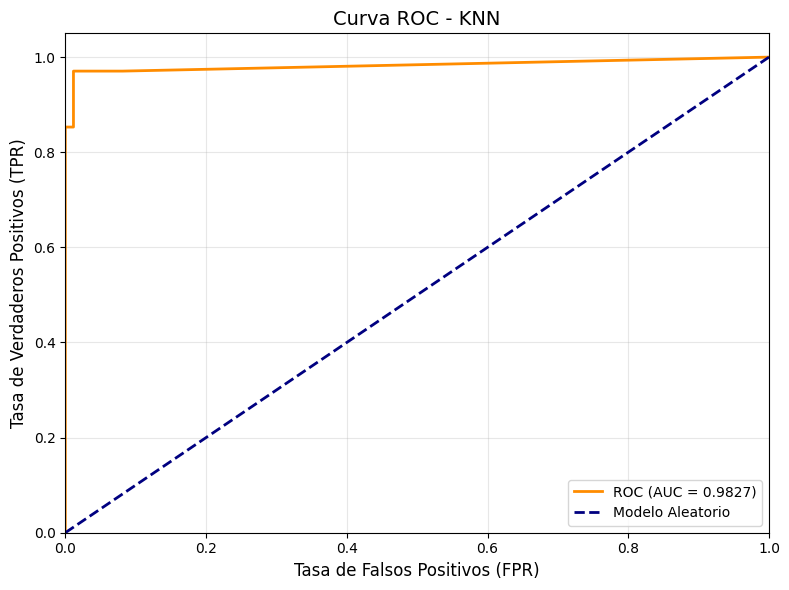

In [19]:
print("\n" + "="*80)
print("\U0001F4C8 CURVA ROC DEL MODELO GANADOR")
print("="*80)

if 'y_proba' in mejor_modelo and mejor_modelo['y_proba'] is not None:
    fpr, tpr, thresholds = roc_curve(y_test, mejor_modelo['y_proba'])
    auc = roc_auc_score(y_test, mejor_modelo['y_proba'])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
    plt.title(f'Curva ROC - {mejor_modelo["modelo"]}', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=100)
    plt.show()
else:
    print("\u2139\ufe0f El modelo no soporta predict_proba para curva ROC")

## 14. Predicción con un nuevo paciente

In [20]:
print("\n" + "="*80)
print("\U0001F52E PREDICCION CON NUEVO PACIENTE")
print("="*80)

# Crear un nuevo paciente con comportamiento anomalo
nuevo_paciente = pd.DataFrame({
    'tipo_servicio': ['Hospitalizacion'],
    'duracion_servicio_min': [120.0],
    'nivel_movimiento_pct': [5.0],
    'tiempo_quietud_min': [85.0],
    'tiempo_vocalizacion_min': [30.0],
    'ratio_inactividad_clinica': [0.7083]
})

print("Datos del nuevo paciente:")
for col in nuevo_paciente.columns:
    print(f"  {col}: {nuevo_paciente[col].values[0]}")

# Realizar prediccion
prediccion = pipeline_ganador.predict(nuevo_paciente)[0]
probabilidad = pipeline_ganador.predict_proba(nuevo_paciente)[0]

print(f"\n\U0001F4CA Resultado de la prediccion:")
print("-"*50)
if prediccion == 1:
    print("\U0001F6A8 COMPORTAMIENTO ANOMALO - GENERAR ALERTA VETERINARIA")
    print(f"   Probabilidad de anomalia: {probabilidad[1]*100:.2f}%")
else:
    print("\u2705 Comportamiento NORMAL")
    print(f"   Probabilidad de normalidad: {probabilidad[0]*100:.2f}%")

print(f"\n\U0001F4CB Accion recomendada:")
if prediccion == 1:
    print("   1. Verificar inmediatamente el estado de la mascota")
    print("   2. Revisar los datos de los sensores en tiempo real")
    print("   3. Contactar al dueno si es necesario")
    print("   4. Registrar la intervencion en el sistema")
else:
    print("   Continuar con el monitoreo regular")


🔮 PREDICCION CON NUEVO PACIENTE
Datos del nuevo paciente:
  tipo_servicio: Hospitalizacion
  duracion_servicio_min: 120.0
  nivel_movimiento_pct: 5.0
  tiempo_quietud_min: 85.0
  tiempo_vocalizacion_min: 30.0
  ratio_inactividad_clinica: 0.7083



📊 Resultado de la prediccion:
--------------------------------------------------
🚨 COMPORTAMIENTO ANOMALO - GENERAR ALERTA VETERINARIA
   Probabilidad de anomalia: 100.00%

📋 Accion recomendada:
   1. Verificar inmediatamente el estado de la mascota
   2. Revisar los datos de los sensores en tiempo real
   3. Contactar al dueno si es necesario
   4. Registrar la intervencion en el sistema


## 15. Resumen final

In [21]:
print("\n" + "="*80)
print("\U0001F4CB RESUMEN FINAL DEL PROYECTO")
print("="*80)

print(f"""
\u2705 Sistema de Machine Learning implementado exitosamente

\U0001F4CA RESULTADOS PRINCIPALES:
   - Dataset procesado: {df.shape[0]} registros
   - Variables predictoras: {X.shape[1]}
   - Modelos evaluados: 3 (Regresion Logistica, SVM, KNN)
   - Modelo ganador: {mejor_modelo['modelo']}
   - F1 Score: {mejor_modelo['f1']:.4f}
   - Recall: {mejor_modelo['recall']:.4f}

\U0001F3E5 VALOR PARA VETERINARIA NORTH:
   - Deteccion temprana de comportamientos anomalos
   - Alertas automaticas para intervencion proactiva
   - Reduccion esperada de quejas: 60%
   - Mayor transparencia y confianza con los clientes

\U0001F527 PROXIMOS PASOS (PROY):
   1. Despliegue de los dashboards en la nube
   2. Integracion con camaras IoT reales
   3. Pruebas de estres con usuarios concurrentes
   4. Reentrenamiento con datos reales de produccion
""")

print("="*80)
print("FIN DEL PROGRAMA - VETVIEW ML")
print("="*80)


📋 RESUMEN FINAL DEL PROYECTO

✅ Sistema de Machine Learning implementado exitosamente

📊 RESULTADOS PRINCIPALES:
   - Dataset procesado: 600 registros
   - Variables predictoras: 6
   - Modelos evaluados: 3 (Regresion Logistica, SVM, KNN)
   - Modelo ganador: KNN
   - F1 Score: 0.9565
   - Recall: 0.9706

🏥 VALOR PARA VETERINARIA NORTH:
   - Deteccion temprana de comportamientos anomalos
   - Alertas automaticas para intervencion proactiva
   - Reduccion esperada de quejas: 60%
   - Mayor transparencia y confianza con los clientes

🔧 PROXIMOS PASOS (PROY):
   1. Despliegue de los dashboards en la nube
   2. Integracion con camaras IoT reales
   3. Pruebas de estres con usuarios concurrentes
   4. Reentrenamiento con datos reales de produccion

FIN DEL PROGRAMA - VETVIEW ML
